In [1]:
print("helo")

helo


In [34]:
# Core
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model Selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Persistence
import joblib

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df["Partner"].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [9]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [10]:
gender_map = {"Male": 1, "Female": 0}
other_map = {"Yes": 1, "No": 0}

In [11]:
cols_for_maping = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

In [12]:
df["gender"] = df["gender"].map(gender_map)

for col in cols_for_maping:
    df[col] = df[col].map(other_map).astype(int)

In [13]:
cols_for_dummies = ["MultipleLines", "OnlineSecurity", "InternetService", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

In [14]:
df = pd.get_dummies(df, columns=cols_for_dummies, drop_first=True, dtype=int)

In [15]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [16]:
df = df.drop(["customerID"], axis=1)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,No,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,No,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,Yes,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,No,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,Yes,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [18]:
df.shape

(7032, 31)

In [19]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [20]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleLines_Yes   

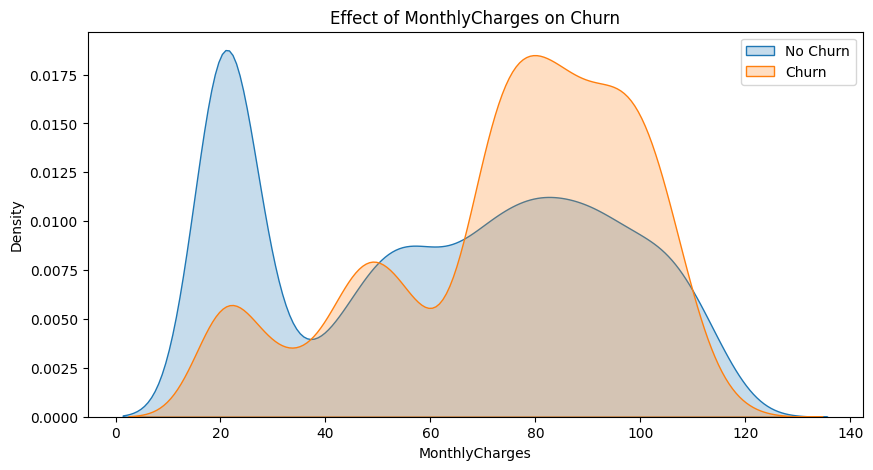

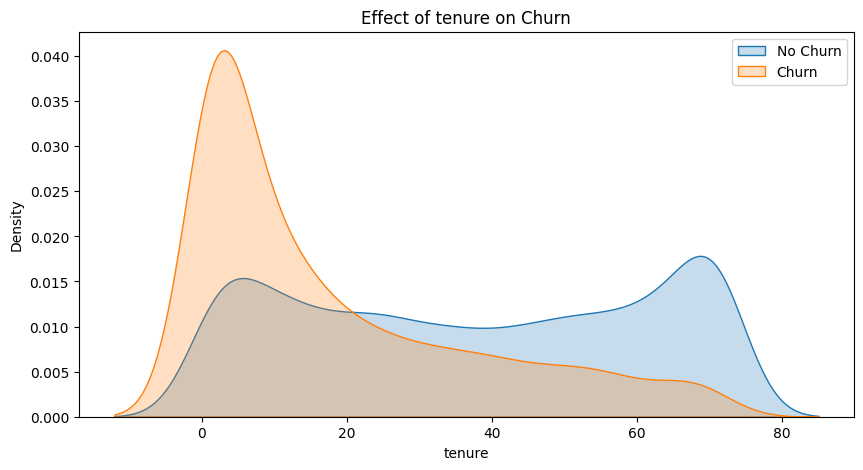

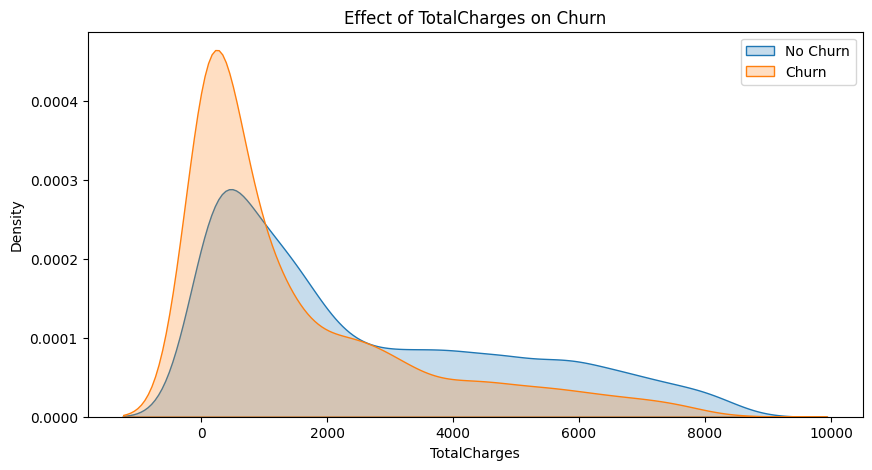

In [22]:
def plot_numerical_effect(column_name):
    plt.figure(figsize=(10, 5))
    plt.title(f'Effect of {column_name} on Churn')
    
    sns.kdeplot(df[df['Churn'] == 0][column_name], label='No Churn', fill=True)
    sns.kdeplot(df[df['Churn'] == 1][column_name], label='Churn', fill=True)
    
    plt.legend()
    plt.show()


plot_numerical_effect('MonthlyCharges')
plot_numerical_effect('tenure')
plot_numerical_effect('TotalCharges')

In [23]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [25]:
model_params = {

    "Logistic_Regression": {
        "model": LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=3000
        ),
        "params": {"C": [0.1, 1, 10, 50, 100]}
,
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },

    "Random_Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
      "n_estimators": [300, 400, 500],
      "max_depth": [7, 8, 9],
      "min_samples_leaf": [8, 10, 12]
    }
    ,
        "X_train": X_train,
        "X_test": X_test
    },

    "SVM": {
        "model": SVC(
            class_weight="balanced",
            probability=True,
            random_state=42
        ),
        "params": {
          "C": [0.5, 1, 5, 10],
          "kernel": ["rbf"],
          "gamma": ["scale"]
    }
    ,
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },

    "XGBoost": {
        "model": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ),
        "params": {
          "max_depth": [3, 4],
          "learning_rate": [0.03, 0.05],
          "subsample": [0.8],
          "colsample_bytree": [0.8]
    }
    ,
        "X_train": X_train,
        "X_test": X_test
    }
}

In [26]:
best_models = {}

for name, mp in model_params.items():
    print(f"\nTraining {name}...")

    if name == "Random_Forest":
        search = RandomizedSearchCV(
            estimator=mp["model"],
            param_distributions=mp["params"],
            scoring="roc_auc",
            cv=5,
            n_iter=15,
            random_state=42,
            n_jobs=-1
        )
    else:
        search = GridSearchCV(
            estimator=mp["model"],
            param_grid=mp["params"],   
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        )
        
    search.fit(mp["X_train"], y_train)

    best_models[name] = {
        "model": search.best_estimator_,
        "X_test": mp["X_test"]
    }

    print("Best Params:", search.best_params_)
    print("CV ROC-AUC:", search.best_score_)



Training Logistic_Regression...
Best Params: {'C': 100}
CV ROC-AUC: 0.8458594831844648

Training Random_Forest...
Best Params: {'n_estimators': 400, 'min_samples_leaf': 10, 'max_depth': 8}
CV ROC-AUC: 0.8478892515001579

Training SVM...
Best Params: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
CV ROC-AUC: 0.8292253435584312

Training XGBoost...
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.8}
CV ROC-AUC: 0.8469992792763611



===== Logistic_Regression =====
ROC-AUC: 0.8341715371354914

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.53      0.68      1033
           1       0.41      0.93      0.57       374

    accuracy                           0.63      1407
   macro avg       0.68      0.73      0.63      1407
weighted avg       0.81      0.63      0.65      1407



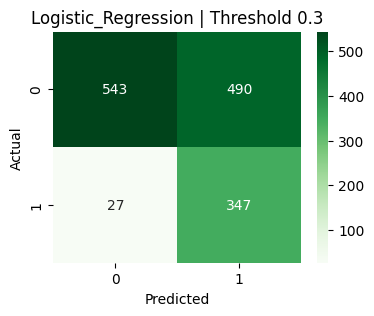


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.62      0.74      1033
           1       0.45      0.87      0.59       374

    accuracy                           0.68      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.68      0.70      1407



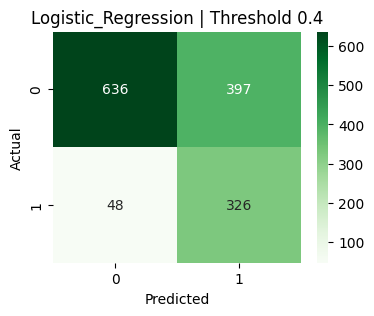


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407



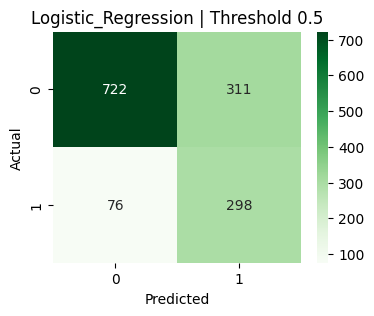


===== Random_Forest =====
ROC-AUC: 0.8406243690823159

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.54      0.69      1033
           1       0.42      0.91      0.57       374

    accuracy                           0.64      1407
   macro avg       0.68      0.73      0.63      1407
weighted avg       0.80      0.64      0.66      1407



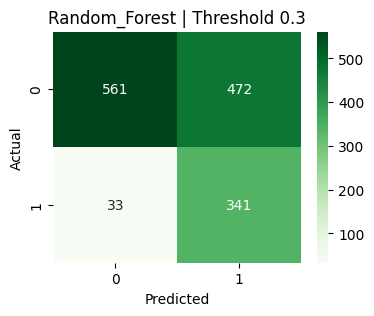


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1033
           1       0.46      0.86      0.60       374

    accuracy                           0.69      1407
   macro avg       0.69      0.75      0.68      1407
weighted avg       0.80      0.69      0.71      1407



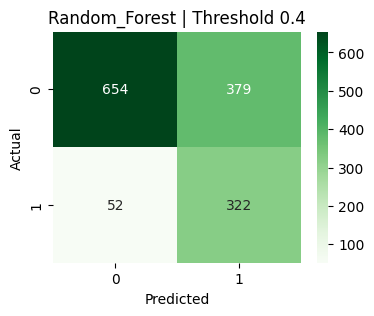


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



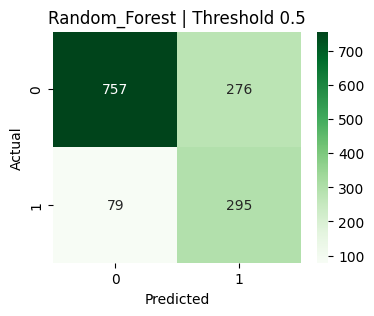


===== SVM =====
ROC-AUC: 0.8104645624860876

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.74      0.75      1407



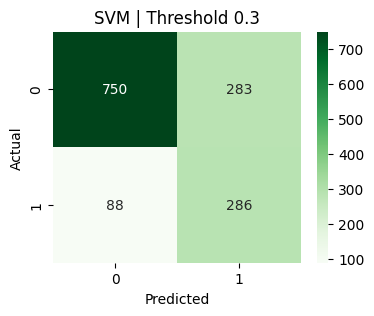


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.54      0.73      0.62       374

    accuracy                           0.76      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.76      0.77      1407



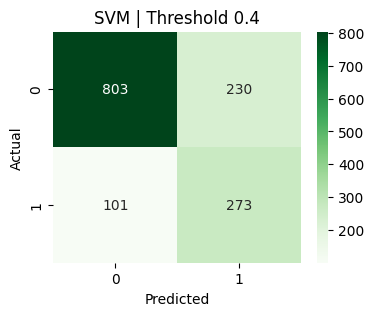


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1033
           1       0.58      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



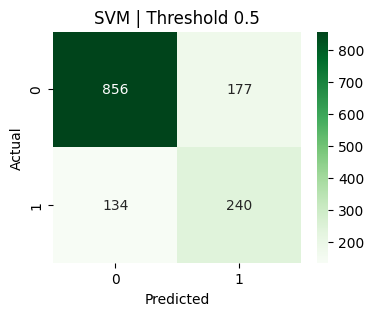


===== XGBoost =====
ROC-AUC: 0.8354864342991443

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.58      0.71      1033
           1       0.43      0.90      0.58       374

    accuracy                           0.66      1407
   macro avg       0.69      0.74      0.65      1407
weighted avg       0.80      0.66      0.68      1407



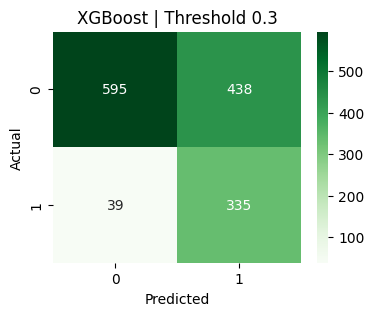


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.64      0.76      1033
           1       0.46      0.85      0.60       374

    accuracy                           0.70      1407
   macro avg       0.69      0.75      0.68      1407
weighted avg       0.80      0.70      0.72      1407



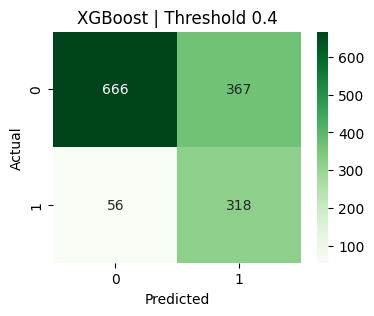


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



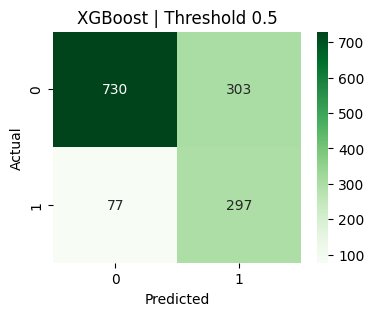

In [27]:
for name, obj in best_models.items():
    model = obj["model"]
    X_test_used = obj["X_test"]

    y_probs = model.predict_proba(X_test_used)[:, 1]
    auc = roc_auc_score(y_test, y_probs)

    print(f"\n===== {name} =====")
    print("ROC-AUC:", auc)

    for threshold in [0.3, 0.4, 0.5]:
        print(f"\nThreshold: {threshold}")
        y_pred = (y_probs >= threshold).astype(int)

        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
        plt.title(f"{name} | Threshold {threshold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


In [28]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
Scale = StandardScaler()
X_scaled = Scale.fit_transform(X)

In [29]:
joblib.dump(Scale, "artifacts/scaler.pkl")
joblib.dump(X.columns.tolist(), "artifacts/feature_names.pkl")

['artifacts/feature_names.pkl']

In [35]:
best_lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
    C=100,
    class_weight="balanced",
    solver="liblinear",
    max_iter=3000
    ))
])

In [36]:
best_rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [37]:
best_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [38]:
hard_voting = VotingClassifier(
    estimators=[
        ("lr", best_lr_pipe),
        ("rf", best_rf),
        ("xgb", best_xgb),
    ],
    voting="hard"
)

hard_voting.fit(X, y)
joblib.dump(hard_voting, "models/voting_hard.pkl")

['models/voting_hard.pkl']

In [39]:
soft_voting = VotingClassifier(
    estimators=[
        ("lr", best_lr_pipe),
        ("rf", best_rf),
        ("xgb", best_xgb),
    ],
    voting="soft"
)

soft_voting.fit(X, y)
joblib.dump(soft_voting, "models/voting_soft.pkl")

['models/voting_soft.pkl']

In [40]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,InternetService_Fiber optic,InternetService_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
